In [22]:
from tools import load_record_numbers, show_confusion_matrix, count_parameters, train, save_weights, train_metrics
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from dataclasses import dataclass

In [23]:
from models import MITBIHDataset as ARDataset
from models import ClassicCNN, CNNWithEncoder

Загрузка и предобработка данных

In [24]:
# Путь к директории с файлами MIT-BIH Arrhythmia Dataset
data_path = Path('../mit-bih-arrhytmia-database')

In [25]:
# Список всех записей в наборе данных (обычно номера записей)
record_numbers = load_record_numbers(data_path)

In [26]:
# Уникальные метки для классификации
labels = ['N', 'V', 'A', 'R', 'L']
print(record_numbers)

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


Создание PyTorch загрузчиков для моделей

In [27]:
@dataclass
class Loader:
    train: DataLoader
    valid: DataLoader
    test: DataLoader

Инициализация интерфейсов (датасета) для взаимодействия с данными

In [29]:
from time import time

In [30]:
start = time()
dataset = ARDataset(record_numbers, path=data_path, labels=labels)
print(time() - start)

56.20037221908569


Разделение выборок и инициализация загрузчиков данных

In [9]:
test_size = 0.2
valid_size = 0.3
batch_size = 64

In [10]:
train_, test = train_test_split(dataset, test_size=test_size)
train_, valid = train_test_split(train_, test_size=valid_size)

loader = Loader(
    train=DataLoader(train_, batch_size=batch_size, shuffle=True),
    valid=DataLoader(valid, batch_size=batch_size, shuffle=False),
    test=DataLoader(test, batch_size=batch_size, shuffle=False),
)

Инициализация моделей и гиперпараметров

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [12]:
num_classes = len(labels)
num_epochs = 25
lr = 1e-3
criterion = nn.CrossEntropyLoss().to(device)

In [13]:
cnn_model = ClassicCNN(num_classes).to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=lr)
count_parameters(cnn_model)

284069

In [14]:
encoder_model = CNNWithEncoder(num_classes).to(device)
encoder_optimizer = torch.optim.Adam(encoder_model.parameters(), lr=lr)
count_parameters(encoder_model)

206949

Обучение моделей

In [17]:
cnn_train_losses, cnn_val_losses, cnn_val_accuracies = train(model=cnn_model,
                                                             trainloader=loader.train,
                                                             valloader=loader.valid,
                                                             criterion=criterion,
                                                             optimizer=cnn_optimizer,
                                                             device=device,
                                                             num_epochs=num_epochs)

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\mrtsstlrs\PycharmProjects\researchwork\venv\Lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/25, Loss: 0.2375747508003057, Validation Accuracy: 96.44%
Epoch 2/25, Loss: 0.11395990615164835, Validation Accuracy: 97.23%
Epoch 3/25, Loss: 0.09210202855896772, Validation Accuracy: 97.43%
Epoch 4/25, Loss: 0.07640191690921626, Validation Accuracy: 97.64%
Epoch 5/25, Loss: 0.06606437315495464, Validation Accuracy: 97.66%
Epoch 6/25, Loss: 0.059469947235410325, Validation Accuracy: 97.98%
Epoch 7/25, Loss: 0.051526389223821654, Validation Accuracy: 98.13%
Epoch 8/25, Loss: 0.04616821769745457, Validation Accuracy: 98.01%
Epoch 9/25, Loss: 0.041799935329571436, Validation Accuracy: 98.05%
Epoch 10/25, Loss: 0.03661200445401013, Validation Accuracy: 98.07%
Epoch 11/25, Loss: 0.03190110436436776, Validation Accuracy: 97.61%
Epoch 12/25, Loss: 0.028587694531270875, Validation Accuracy: 98.13%
Epoch 13/25, Loss: 0.026029830010527007, Validation Accuracy: 98.22%
Epoch 14/25, Loss: 0.023422670234882165, Validation Accuracy: 98.09%
Epoch 15/25, Loss: 0.021458880763246705, Validation 

In [16]:
from tools import test

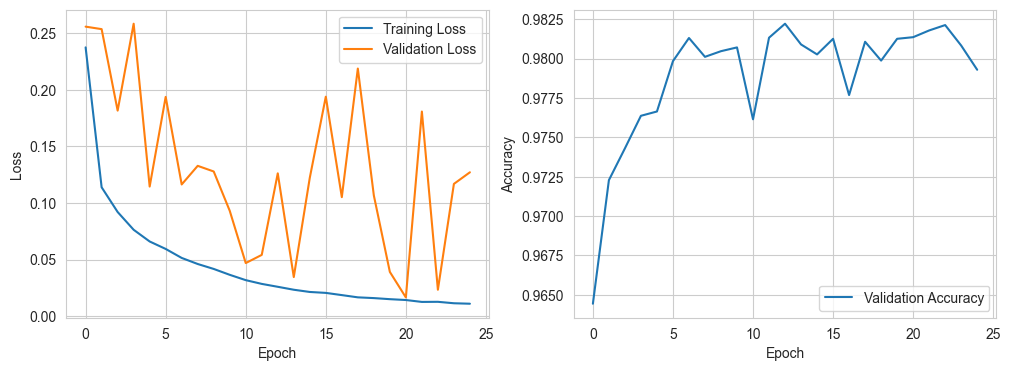

In [19]:
train_metrics(cnn_train_losses, cnn_val_losses, cnn_val_accuracies)

In [20]:
cnn_accuracy, cnn_labels_test, cnn_preds_test = test(model=cnn_model, test_loader=loader.test, device=device)

Final Test Accuracy: 97.89%


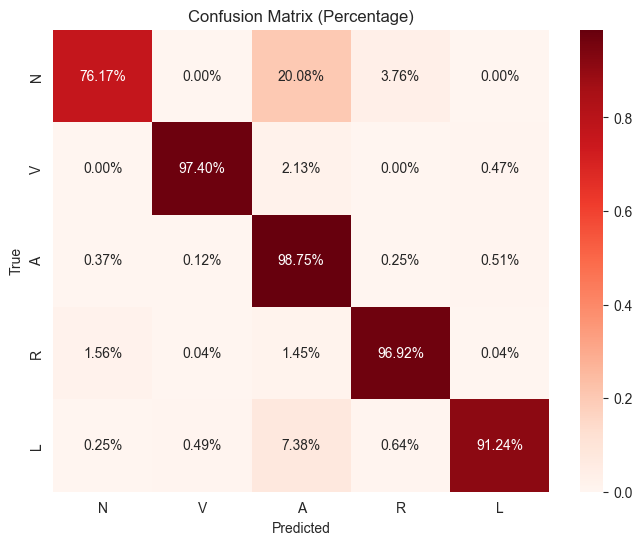

In [21]:
show_confusion_matrix(cnn_labels_test, cnn_preds_test, labels)

Обучение CNN с энкодером

In [15]:
encoder_train_losses, encoder_val_losses, encoder_val_accuracies = train(model=encoder_model,
                                                             trainloader=loader.train,
                                                             valloader=loader.valid,
                                                             criterion=criterion,
                                                             optimizer=encoder_optimizer,
                                                             device=device,
                                                             num_epochs=num_epochs)

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\mrtsstlrs\PycharmProjects\researchwork\venv\Lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/25, Loss: 0.23516412924990876, Validation Accuracy: 96.21%
Epoch 2/25, Loss: 0.11625749179399172, Validation Accuracy: 97.16%
Epoch 3/25, Loss: 0.0941663026135979, Validation Accuracy: 97.68%
Epoch 4/25, Loss: 0.08372318507331536, Validation Accuracy: 97.75%
Epoch 5/25, Loss: 0.07435859189588408, Validation Accuracy: 97.56%
Epoch 6/25, Loss: 0.06889760823535265, Validation Accuracy: 97.90%
Epoch 7/25, Loss: 0.061976264459262194, Validation Accuracy: 97.81%
Epoch 8/25, Loss: 0.05682808348454493, Validation Accuracy: 98.19%
Epoch 9/25, Loss: 0.05298011309405692, Validation Accuracy: 98.20%
Epoch 10/25, Loss: 0.04927977081622922, Validation Accuracy: 98.06%
Epoch 11/25, Loss: 0.04549959857805785, Validation Accuracy: 98.27%
Epoch 12/25, Loss: 0.04157387552934839, Validation Accuracy: 98.28%
Epoch 13/25, Loss: 0.03891333853417136, Validation Accuracy: 98.33%
Epoch 14/25, Loss: 0.03670659605696936, Validation Accuracy: 98.25%
Epoch 15/25, Loss: 0.03280915989858926, Validation Accura

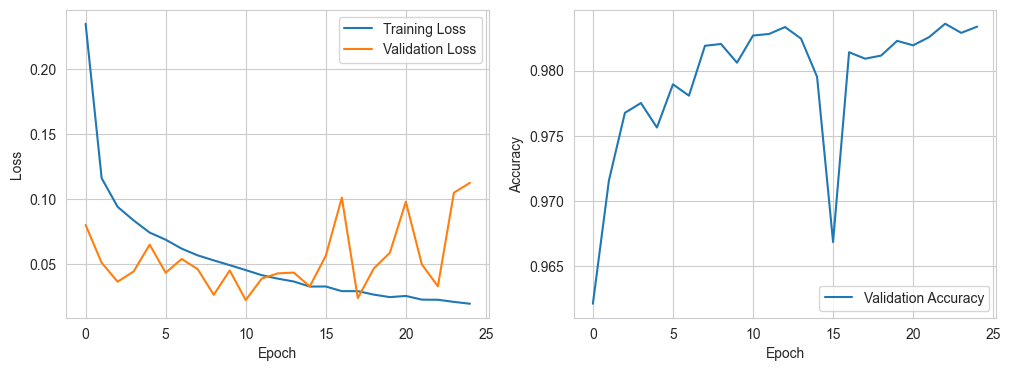

In [17]:
train_metrics(encoder_train_losses, encoder_val_losses, encoder_val_accuracies)

In [18]:
encoder_accuracy, encoder_labels_test, encoder_preds_test = test(model=encoder_model, test_loader=loader.test, device=device)

Final Test Accuracy: 98.17%


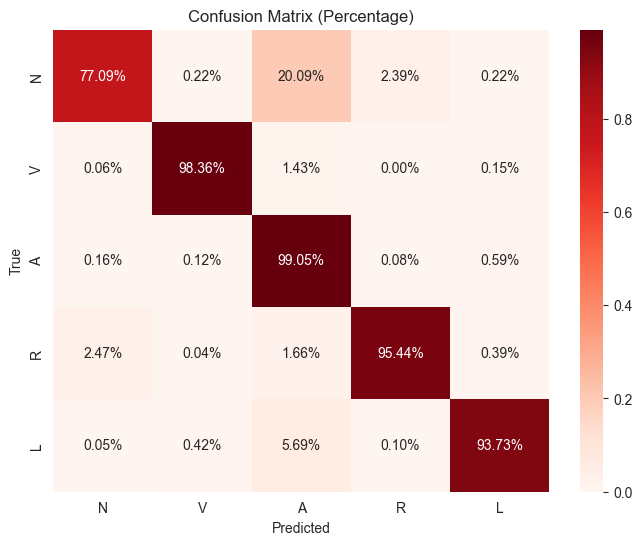

In [19]:
show_confusion_matrix(encoder_labels_test, encoder_preds_test, labels)  